# Quickstart

In [1]:
import datetime
import geospacelab.datahub as datahub
import geospacelab.visualization.mpl as gsl_mpl

## Swarm Data Access

### Initial settings

In [2]:
dt_fr = datetime.datetime(2016, 3, 15, 18, 18)
dt_to = datetime.datetime(2016, 3, 15, 18, 23)
dt_tsat_id = "A"

### Create a datahub

In [3]:

dh = datahub.DataHub(dt_fr=dt_fr, dt_to=dt_to, visual='on')

### Dock a Swarm dataset

Docking a dataset is the process of loading the dataset into the datahub. It is done by calling the `dock` method of the datahub object. The method takes the name patterns of the dataset as an argument and returns a dataset object.

The following code docks the Swarm MAG LR dataset for the specified time range (shown above) and satellite ID. A full list of the supported datasets and their name patterns can be found in the [Supported datasets](2_supported_datasets.ipynb) tutorial.

In [4]:
ds = dh.dock(datasource_contents=['esa_eo', 'swarm', 'l1b', 'mag_lr'], sat_id='A', add_APEX=True,)

Load IGRF coefficients ...


Searching the data product "MAG_LR" with the version "latest" on the server...
The file [PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level1b/MAG_LR/0701/Sat_A/2016/SW_OPER_MAGA_LR_1B_20160315T000000_20160315T235959_0701_MDR_MAG_LR.cdf'), PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level1b/MAG_LR/0701/Sat_A/2016/SW_OPER_MAGA_LR_1B_20160315T000000_20160315T235959_0701_ASM_VFM_IC.cdf')] already exists: skip downloading.
/opt/anaconda3/envs/Swarm/lib/python3.12/site-packages/numpy/_core/numeric.py:476: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


#### List loaded variables

In [11]:
ds.list_all_variables()

Dataset: esa/earthonline | swarm | mag | mag_lr
Printing all of the variables ...
        No.                 Variable name         
         1          SC_DATETIME                   
         2          SYNC_STATUS                   
         3          SC_GEO_LAT                    
         4          SC_GEO_LON                    
         5          SC_GEO_r                      
         6          B_VFM                         
         7          B_VFM_x                       
         8          B_VFM_y                       
         9          B_VFM_z                       
         10         B_VFM_x_err                   
         11         B_VFM_y_err                   
         12         B_VFM_z_err                   
         13         B_NEC                         
         14         B_N                           
         15         B_E                           
         16         B_C                           
         17         dB_Sun_VFM                    


#### Get a variable and data array

In [9]:
B_N = ds['B_N']
B_N

GeospaceLab Variable object <name: B_N, value: array([[3575.961 ],
       [3589.4286],
       [3602.0871],
       [3615.2638],
       [3628.8496],
       [3641.281 ],
       [3655.2118],
       [3669.2406],
       [3682.6516],
       [3694.7944],
       [3707.2074],
       [3720.5099],
       [3734.2823],
       [3748.459 ],
       [3762.2163],
       [3775.9528],
       [3789.8617],
       [3804.0013],
       [3818.1571],
       [3832.7576],
       [3847.7012],
       [3862.9891],
       [3877.1063],
       [3891.5415],
       [3906.5735],
       [3921.5674],
       [3936.6122],
       [3952.1547],
       [3966.2276],
       [3981.2328],
       [3996.0637],
       [4011.7886],
       [4028.14  ],
       [4045.5358],
       [4061.1698],
       [4075.8638],
       [4091.0254],
       [4106.588 ],
       [4122.35  ],
       [4137.4961],
       [4153.7856],
       [4169.0038],
       [4185.0942],
       [4200.7928],
       [4217.3782],
       [4234.4431],
       [4251.3268],
       [4267.

In [10]:

B_N_arr = B_N.value
B_N_arr

array([[3575.961 ],
       [3589.4286],
       [3602.0871],
       [3615.2638],
       [3628.8496],
       [3641.281 ],
       [3655.2118],
       [3669.2406],
       [3682.6516],
       [3694.7944],
       [3707.2074],
       [3720.5099],
       [3734.2823],
       [3748.459 ],
       [3762.2163],
       [3775.9528],
       [3789.8617],
       [3804.0013],
       [3818.1571],
       [3832.7576],
       [3847.7012],
       [3862.9891],
       [3877.1063],
       [3891.5415],
       [3906.5735],
       [3921.5674],
       [3936.6122],
       [3952.1547],
       [3966.2276],
       [3981.2328],
       [3996.0637],
       [4011.7886],
       [4028.14  ],
       [4045.5358],
       [4061.1698],
       [4075.8638],
       [4091.0254],
       [4106.588 ],
       [4122.35  ],
       [4137.4961],
       [4153.7856],
       [4169.0038],
       [4185.0942],
       [4200.7928],
       [4217.3782],
       [4234.4431],
       [4251.3268],
       [4267.0587],
       [4284.2821],
       [4301.6056],


## Swarm Data Visualization

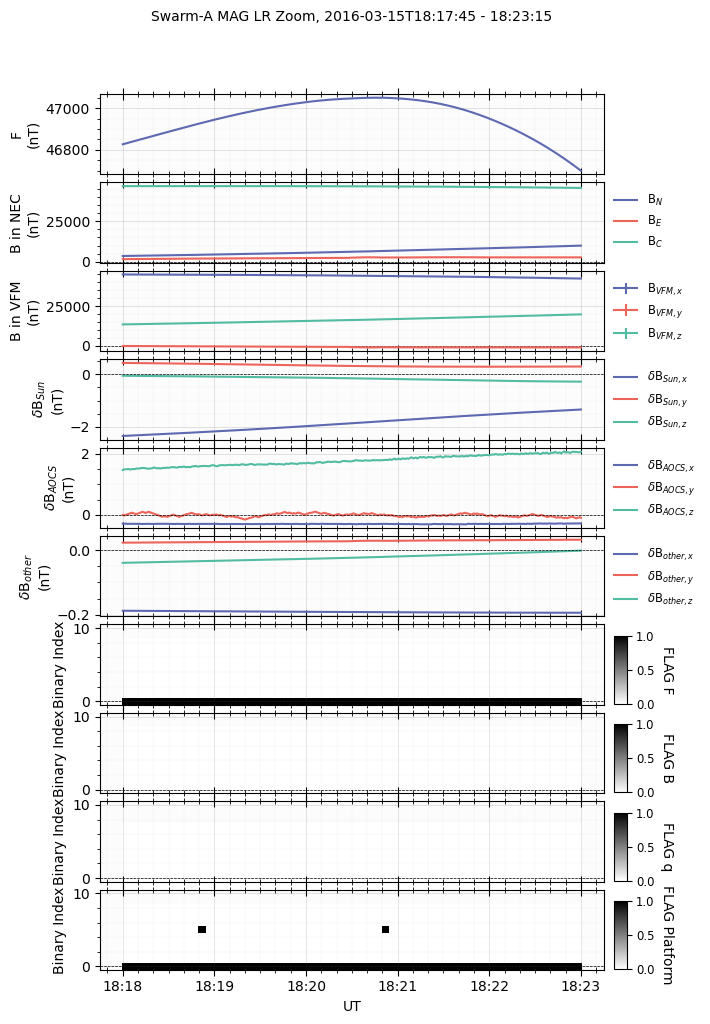

In [8]:
fig = gsl_mpl.create_figure(figsize=(8, 12))
db = gsl_mpl.dashboards.TSDashboard(figure=fig)

panel_layouts = [
    [ds['F']],
        [ds['B_N'], ds['B_E'], ds['B_C']],
        [ds['B_VFM_x'], ds['B_VFM_y'], ds['B_VFM_z']],
        [ds['dB_Sun_VFM_x'], ds['dB_Sun_VFM_y'], ds['dB_Sun_VFM_z']],
        [ds['dB_AOCS_VFM_x'], ds['dB_AOCS_VFM_y'], ds['dB_AOCS_VFM_z']],
        [ds['dB_other_VFM_x'], ds['dB_other_VFM_y'], ds['dB_other_VFM_z']],
        [ds['FLAG_F_BIN_AUX']],
        [ds['FLAG_B_BIN_AUX']],
        [ds['FLAG_q_BIN_AUX']],
        [ds['FLAG_Platform_BIN_AUX']],
    ]
db.set_layout(panel_layouts)
db.draw()
db.add_title(title='Swarm-{} MAG LR Zoom'.format(ds.sat_id), fontsize='medium', append_time=True)
db.show() 